### 1.b Take the sampregdata and build a linear regression model with scikit-learn, using the 1 X that fits the best. Put the model and the data in a proper organization.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("sampregdata.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5394 entries, 0 to 5393
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5394 non-null   int64  
 1   x1          5394 non-null   float64
 2   x2          5394 non-null   float64
 3   x3          5394 non-null   float64
 4   x4          5394 non-null   float64
 5   y           5394 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 253.0 KB


In [5]:
df.head()

,Unnamed: 0,x1,x2,x3,x4,y
0,1,7.331693,9.660958,-2.981869,5.214284,-2.311878
1,2,16.888609,9.546231,18.440459,11.804018,0.994307
2,3,8.280643,6.442062,-0.225791,6.493211,-5.253876
3,4,3.827778,3.741506,-2.850664,-0.226420,20.056798
4,5,9.675971,4.385008,8.344576,5.979043,9.577914


In [7]:
dfuse = df.iloc[:,1:6]
dfuse.head()

,x1,x2,x3,x4,y
0,7.331693,9.660958,-2.981869,5.214284,-2.311878
1,16.888609,9.546231,18.440459,11.804018,0.994307
2,8.280643,6.442062,-0.225791,6.493211,-5.253876
3,3.827778,3.741506,-2.850664,-0.226420,20.056798
4,9.675971,4.385008,8.344576,5.979043,9.577914


In [10]:
x_cols = ['x1', 'x2', 'x3', 'x4']
corr = dfuse[x_cols].corrwith(dfuse['y'])
print(corr)

x1    0.005234
x2   -0.471165
x3    0.432279
x4   -0.524394
dtype: float64


Using heatmap to see is Another way:

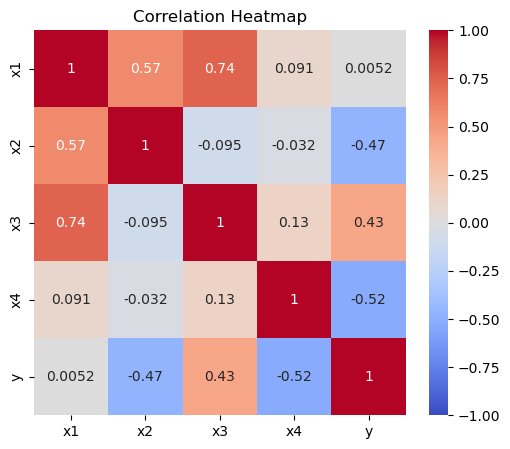

In [11]:
import seaborn as sns
corr_matrix = dfuse.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

#### As we can see, the correlation is the strongest between x4 and y. we will use x4 as the data to build Linear Regression model.

In [17]:
dfx4 = df[['x4']]
y = df['y']
dfx4.head()

,x4
0,5.214284
1,11.804018
2,6.493211
3,-0.226420
4,5.979043


In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(dfx4, y)
print(model.intercept_, model.coef_)

8.75070515395152 [-1.22445664]


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


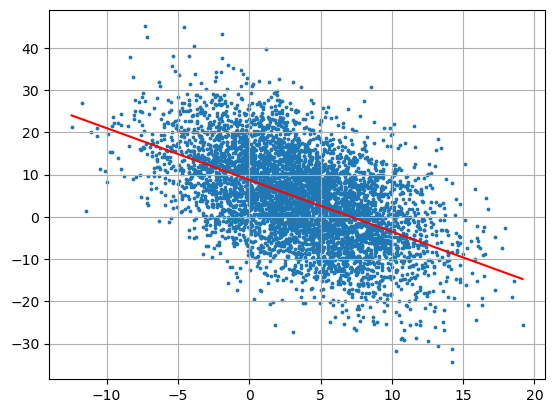

In [35]:
x_range = np.linspace(dfx4.min(), dfx4.max(), 100).reshape(-1, 1)
y_pred = model.predict(x_range)
plt.plot(x_range, y_pred, color='red')
plt.scatter(dfx4,y,s=3)
plt.grid()
plt.show()

In [37]:
print(model.score(dfx4, y)) #R^2

0.27498888457029635


In [41]:
#Train-test split 80/20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dfx4, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
print("Train R²:", model.score(X_train, y_train))
print("Test R²:", model.score(X_test, y_test))

Train R²: 0.2757219120125677
Test R²: 0.2685542927902339


### 1.c. Create a new model with 2 X’s. Use proper version control to designate this model as the current model while still have the previous model as accessible.

In [22]:
df2 = df[['x4','x2']]
df2.head()

,x4,x2
0,5.214284,9.660958
1,11.804018,9.546231
2,6.493211,6.442062
3,-0.226420,3.741506
4,5.979043,4.385008


In [23]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5394 entries, 0 to 5393
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x4      5394 non-null   float64
 1   x2      5394 non-null   float64
dtypes: float64(2)
memory usage: 84.4 KB


In [28]:
model2 = LinearRegression()
model2.fit(df2, y)
print(model2.coef_, model2.intercept_)

[-1.26146834 -0.84009006] 15.745003662592286


In [39]:
print(model2.score(df2, y)) #R^2

0.5135537867830376


In [42]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(df2, y, test_size=0.2, random_state=44)

model2.fit(X_train2, y_train2)
print("Train R²:", model2.score(X_train2, y_train2))
print("Test R²:", model2.score(X_test2, y_test2))

Train R²: 0.5135415023227408
Test R²: 0.5132465092823735


## 2. The first set of slides mention demand forecasting. For this, suppose you are working with “demand planners” to create demand forecasts for a set of 100 products. They products are small, tangible goods. 

### a. What is a demand planner?

Demand planner is someone that is in charge of the company's inventory list. He/she needs to predict the coming months need based on certain knowledge.

### b. Why would a demand planner need product forecasts?

Because if something is suddenly urgently needed and it is not there, it would be usually extremely costly. 

### c. Based on searching, what is the time frequency most likely needed for these forecasts?

Mostly either weekly/monthly.

### d. What data do you need to get started?

need to get the previous month/week's consumption. Also need previous forecast vs their actual numbers, how much has been overestimate/underestimate etc. 

### e. You are to meet with a couple of the demand planners. What are some questions you would like to ask them?

- how many are needed as expected?

- why do you think the company needs this much?

- how is our historic projection like? 

- how many needs can be satisfied with our current items on our inventory list?

### f. After building the models, how would you show to the demand planners that the results should be trusted?

I need to do model evalutions, especially need to put this model on test for our historic data and historic projection, to see how much it would be close to the historic actual figure, to show that our projection is accurate.

### g. Describe some characteristics of the data that would be needed to productionize the models.

the data has to be clear and usable (can build the model on). For the result, R^2 needs to be high; Train/test accuracies both needs to be high

### h. What is your best guess as to how they would want to receive the model results?

they would love to receive in charts, graphs, pie chart etc., that is easily visualizable. 

### i. What sources did you use to find these answers?

internet; class note; my own work experience beforehand.

## 3. Please see the "Question 3.jpeg" for the answer.

## 4. Please see the "Question 4.jpeg" for the answer.

## 5. Process time simulation

### a. Take the demand forecasting process diagram from the slides. We will simulate with the following random variables for each step

i. SH Analysis: Exponential, mean of 10 days

ii. Data Extract: Normal, mean 15 days, standard deviation 3 days

iii. Dev Exploration: Normal, mean 3 days, standard deviation ½ day

iv. Dev Modeling: Poisson distribution, mean 30 days

v. Process Integration: Normal, mean 50 days, standard deviation 20 days

vi. Data Pipeline: Poisson distribution, mean 100 days

vii. Model Productionization: Normal distribution, mean 30 days, standard deviation 5 days

In [5]:
np.random.seed(42)
N = 1000000
sh_analysis = np.maximum(np.random.exponential(scale=10, size=N), 0)
data_extract = np.maximum(np.random.normal(15, 3, N), 0)
dev_exploration = np.maximum(np.random.normal(3, 0.5, N), 0)
dev_modeling = np.random.poisson(30, N)
process_integration = np.maximum(np.random.normal(50, 20, N), 0)
data_pipeline = np.random.poisson(100, N)
model_productionization = np.maximum(np.random.normal(30, 5, N), 0)

In [18]:
total_time = (sh_analysis + data_extract + dev_exploration + dev_modeling + process_integration + data_pipeline + model_productionization)

### b. Perform 1,000,000 simulations of this process, taking care to account for the dependencies.

1. What is the average and median amount of time for the entire process? What is a 95% (2-sided) confidence interval?

In [11]:
print(f"Average: {total_time.mean():.1f} days")
print(f"Median: {np.median(total_time):.1f} days")
print(f"2.5th percentile: {np.percentile(total_time,2.5):.1f} days")
print(f"97.5th percentile: {np.percentile(total_time,97.5):.1f} days")
print(f"95% confidence interval: between {np.percentile(total_time,2.5):.1f} and {np.percentile(total_time,97.5):.1f} days")

Average: 238.1 days
Median: 237.5 days
2.5th percentile: 189.1 days
97.5th percentile: 290.0 days
95% confidence interval: between 189.1 and 290.0 days


 2. Which step contributes the most towards the overall time and the uncertainty in the overall time?

In [17]:
steps = {
    "SH Analysis": sh_analysis, "Data Extract": data_extract,
    "Dev Exploration": dev_exploration, "Dev Modeling": dev_modeling,
    "Process Integration": process_integration, "Data Pipeline": data_pipeline,
    "Model Productionization": model_productionization,
}

for name, arr in sorted(steps.items(), key = lambda kv: -kv[1].var()):
    print (name, f"mean = {arr.mean():.1f} days, variance = {arr.var():.1f} days")

Process Integration mean = 50.0 days, variance = 396.0 days
SH Analysis mean = 10.0 days, variance = 100.2 days
Data Pipeline mean = 100.0 days, variance = 99.9 days
Dev Modeling mean = 30.0 days, variance = 30.0 days
Model Productionization mean = 30.0 days, variance = 25.0 days
Data Extract mean = 15.0 days, variance = 9.0 days
Dev Exploration mean = 3.0 days, variance = 0.2 days


### The longest overall time is Data Pipeline which takes 100 days, but the biggest uncertainty is Process Integration, which variance is 396 days! 

## ii. Suppose the data engineer who is building the data pipeline leaves the company and the mean value becomes 150 days to build it. What is the average and 95% confidence interval for the length of the delay?

In [23]:
data_pipeline2 = np.random.poisson(150, N)
total_time2 = (sh_analysis + data_extract + dev_exploration + dev_modeling + process_integration + data_pipeline2 + model_productionization)
delay = total_time2 - total_time
print(f"Average: {np.mean(delay):.1f} days")
print(f"2.5th percentile: {np.percentile(delay,2.5):.1f} days")
print(f"97.5th percentile: {np.percentile(delay,97.5):.1f} days")
print(f"95% confidence interval delay time: between {np.percentile(delay,2.5):.1f} and {np.percentile(delay,97.5):.1f} days")

Average: 50.0 days
2.5th percentile: 19.0 days
97.5th percentile: 81.0 days
95% confidence interval delay time: between 19.0 and 81.0 days
